# Sistema de Predicción e Inteligencia Deportiva — Mundial 2026

**Integrantes humanos:** [Integrante 1: datos, MLP y evaluación] · [Integrante 2: LSTM/GRU, simulador y dashboard]. Ambos revisaron la integración y deben reemplazar los marcadores por sus nombres.

Este notebook descarga y prepara datos, compara las arquitecturas obligatorias y reserva el Mundial 2022 como test final.

## 1. Entorno reproducible
Cada línea ejecutable lleva un comentario que explica su propósito. En Colab se debe clonar el repositorio y seleccionar un runtime con GPU.

In [1]:
import os  # permite fijar el directorio de trabajo tanto en local como en Colab
from pathlib import Path  # detecta la raíz del repositorio sin rutas absolutas
project_root = Path.cwd() if (Path.cwd() / 'requirements-colab.txt').exists() else Path.cwd().parent  # resuelve ejecución desde raíz o notebooks
os.chdir(project_root)  # hace que datos, configuración y artefactos usen las mismas rutas
%pip install -q -r requirements-colab.txt  # instala versiones reproducibles sin reemplazar TensorFlow de Colab
%pip install -q -e .  # registra el paquete mundial para reutilizar exactamente el código del dashboard

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json  # permite leer métricas y metadatos generados por el pipeline
from pathlib import Path  # maneja rutas portables entre Linux local y Colab
import matplotlib.pyplot as plt  # dibuja las curvas exigidas por la rúbrica
import numpy as np  # opera ventanas temporales y gradientes numéricos
import pandas as pd  # presenta tablas de datos y resultados
import tensorflow as tf  # implementa MLP, LSTM, GRU y el experimento BPTT
from mundial.config import ARTIFACTS_DIR, PROCESSED_DIR  # centraliza las rutas del proyecto
from mundial.data import save_processed_dataset  # construye features usando solamente el pasado
from mundial.training import train_all  # entrena y compara las cuatro configuraciones obligatorias
tf.keras.utils.set_random_seed(2026)  # fija la aleatoriedad para repetir los resultados
print(tf.config.list_physical_devices('GPU'))  # verifica si TensorFlow utilizará aceleración NVIDIA

I0000 00:00:1782772587.307986 2651039 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1782772587.919062 2651039 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Adquisición y construcción temporal

Para un partido en fecha $t$, todas las variables se calculan con fechas estrictamente anteriores a $t$. Los promedios móviles aplican `shift(1)`, los rankings usan un join hacia atrás y el scaler se ajusta únicamente con entrenamiento.

In [3]:
raw_manifest = Path('data/raw/manifest.json')  # identifica si los cuatro datasets ya fueron descargados
assert raw_manifest.exists(), 'Ejecute primero: python scripts/download_data.py con su token de Kaggle'  # evita entrenar con fuentes incompletas
table_path, sequence_path = save_processed_dataset()  # genera tabla maestra y ventanas de diez partidos
matches = pd.read_parquet(table_path)  # carga el resultado tabular para auditarlo
sequences = np.load(sequence_path)  # carga ambas trayectorias históricas alineadas por partido
display(matches.groupby('split').agg(partidos=('match_id', 'size'), desde=('date', 'min'), hasta=('date', 'max')))  # confirma la separación cronológica
print(sequences['team_a'].shape, sequences['team_b'].shape)  # comprueba lookback diez para ambos equipos

,partidos,desde,hasta
split,,,
production,3713,2022-11-20,2026-06-27
test,64,2022-11-20,2022-12-18
train,4942,2015-01-04,2019-12-29
validation,2324,2020-01-07,2022-11-19


(11043, 10, 5) (11043, 10, 5)


## 3. Arquitecturas y evaluación

La MLP contiene cuatro capas ReLU, L2 en las dos primeras y Dropout. Se compara Adam contra SGD con momentum. LSTM y GRU comparten el mismo diseño de dos capas y reciben por separado las diez observaciones previas de cada selección. Las tres salidas optimizan resultado y goles de manera conjunta.

In [4]:
summary = train_all(max_epochs_mlp=60, max_epochs_recurrent=40)  # entrena MLP-Adam, MLP-SGD, LSTM y GRU con early stopping
metrics = pd.DataFrame(summary['models']).T.sort_values('macro_f1', ascending=False)  # ordena candidatos por el criterio principal
display(metrics[['macro_f1', 'accuracy', 'log_loss', 'brier', 'mae_goals_a', 'mae_goals_b', 'training_seconds']])  # compara calidad y velocidad
print('Modelo seleccionado:', summary['selected_model'])  # documenta el modelo exportado al simulador

Epoch 1/60


20/20 - 3s - 144ms/step - goals_a_loss: 1.0497 - goals_a_mae: 1.2443 - goals_b_loss: 1.0069 - goals_b_mae: 0.9834 - loss: 1.5775 - result_accuracy: 0.4786 - result_loss: 1.0381 - val_goals_a_loss: 0.8375 - val_goals_a_mae: 1.1763 - val_goals_b_loss: 0.9640 - val_goals_b_mae: 0.8828 - val_loss: 1.4050 - val_result_accuracy: 0.5766 - val_result_loss: 0.9303


Epoch 2/60


20/20 - 0s - 20ms/step - goals_a_loss: 0.7851 - goals_a_mae: 1.1966 - goals_b_loss: 0.9469 - goals_b_mae: 0.9394 - loss: 1.4103 - result_accuracy: 0.5573 - result_loss: 0.9571 - val_goals_a_loss: 0.7469 - val_goals_a_mae: 1.0629 - val_goals_b_loss: 0.8802 - val_goals_b_mae: 0.8152 - val_loss: 1.3224 - val_result_accuracy: 0.5972 - val_result_loss: 0.9011


Epoch 3/60


...

20/20 - 0s - 13ms/step - goals_a_loss: 0.6368 - goals_a_mae: 1.0545 - goals_b_loss: 0.8335 - goals_b_mae: 0.8783 - loss: 1.2566 - result_accuracy: 0.5969 - result_loss: 0.8822 - val_goals_a_loss: 0.7027 - val_goals_a_mae: 1.0112 - val_goals_b_loss: 0.8402 - val_goals_b_mae: 0.7893 - val_loss: 1.2698 - val_result_accuracy: 0.5938 - val_result_loss: 0.8886


Epoch 20/40


20/20 - 0s - 10ms/step - goals_a_loss: 0.6363 - goals_a_mae: 1.0541 - goals_b_loss: 0.8270 - goals_b_mae: 0.8718 - loss: 1.2551 - result_accuracy: 0.5931 - result_loss: 0.8811 - val_goals_a_loss: 0.7010 - val_goals_a_mae: 1.0154 - val_goals_b_loss: 0.8396 - val_goals_b_mae: 0.7884 - val_loss: 1.2682 - val_result_accuracy: 0.5921 - val_result_loss: 0.8887


,macro_f1,accuracy,log_loss,brier,mae_goals_a,mae_goals_b,training_seconds
mlp_sgd,0.406619,0.546875,0.996825,0.592683,1.055404,0.832968,6.612208
mlp_adam,0.392435,0.53125,1.002963,0.593807,1.056586,0.840886,6.194411
gru,0.37817,0.5,1.006284,0.597347,1.071902,0.860521,7.987564
lstm,0.36,0.46875,1.049268,0.623254,1.055815,0.854364,4.959289


Modelo seleccionado: mlp_sgd


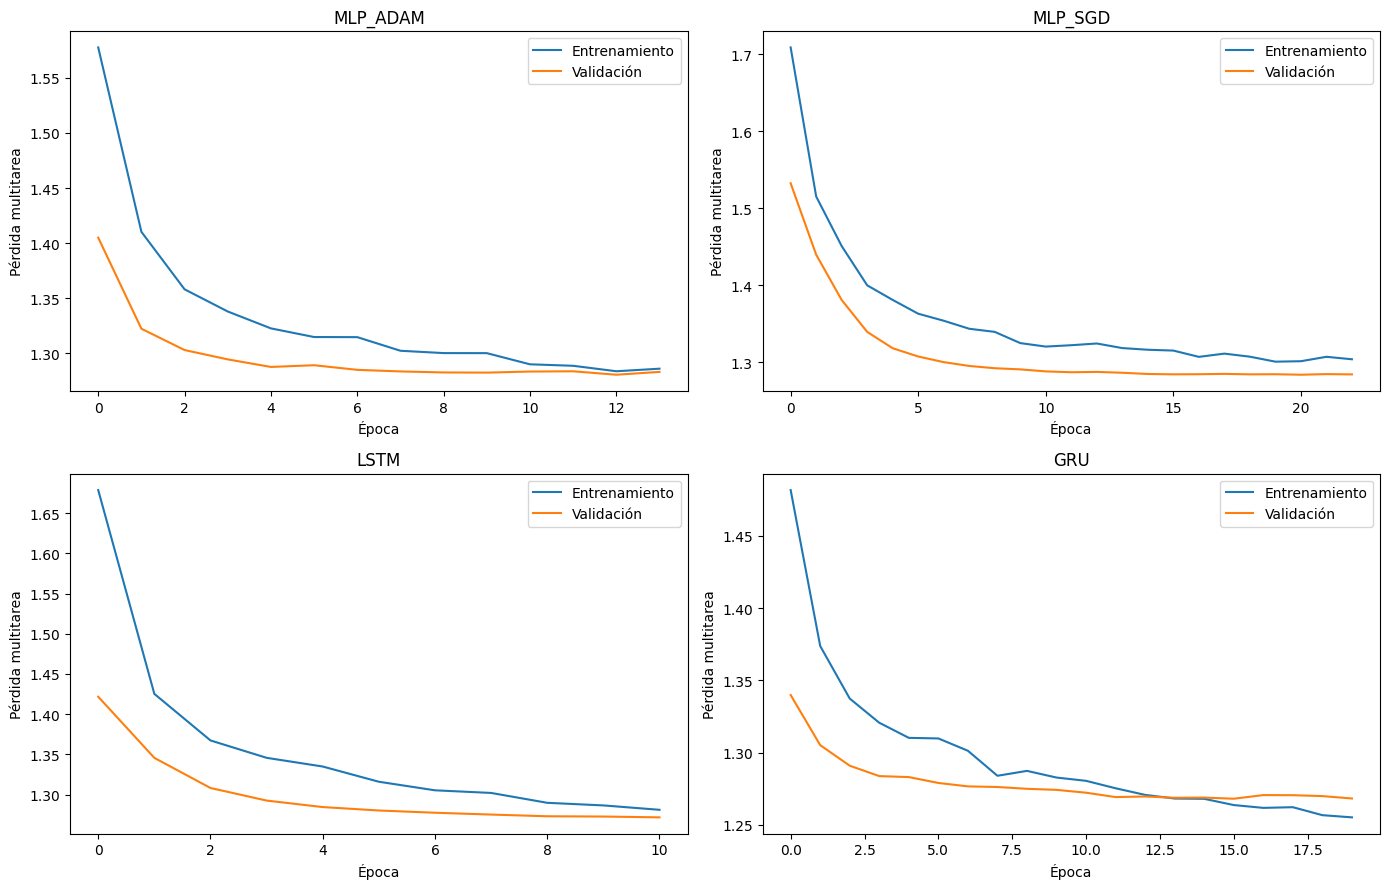

In [5]:
figure, axes = plt.subplots(2, 2, figsize=(14, 9))  # reserva un panel para cada entrenamiento obligatorio
for axis, model_name in zip(axes.ravel(), ['mlp_adam', 'mlp_sgd', 'lstm', 'gru']):  # recorre los cuatro historiales comparables
    history = json.loads((ARTIFACTS_DIR / f'history_{model_name}.json').read_text())  # recupera métricas por época
    axis.plot(history['loss'], label='Entrenamiento')  # muestra la pérdida observada en train
    axis.plot(history['val_loss'], label='Validación')  # muestra generalización y posible sobreajuste
    axis.set_title(model_name.upper())  # etiqueta claramente la arquitectura y optimizador
    axis.set_xlabel('Época')  # identifica el eje temporal de entrenamiento
    axis.set_ylabel('Pérdida multitarea')  # aclara la magnitud representada
    axis.legend()  # distingue las dos curvas
plt.tight_layout()  # evita solapamientos entre títulos y ejes
plt.show()  # renderiza la evidencia requerida

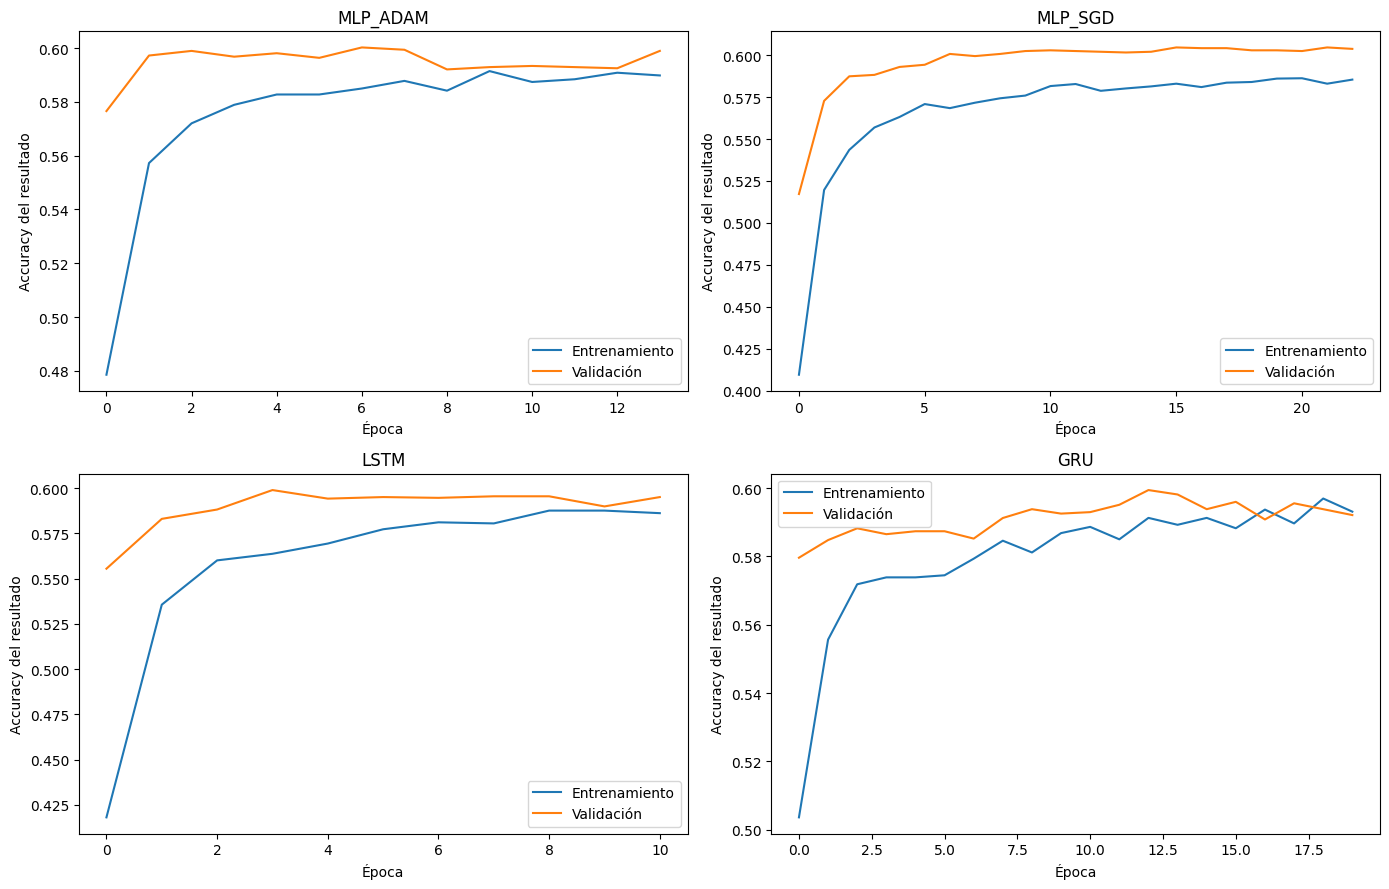

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(14, 9))  # reserva un panel de accuracy para cada entrenamiento
for axis, model_name in zip(axes.ravel(), ['mlp_adam', 'mlp_sgd', 'lstm', 'gru']):  # mantiene el mismo orden de la comparación de loss
    history = json.loads((ARTIFACTS_DIR / f'history_{model_name}.json').read_text())  # recupera las métricas de clasificación
    axis.plot(history['result_accuracy'], label='Entrenamiento')  # muestra accuracy de train por época
    axis.plot(history['val_result_accuracy'], label='Validación')  # muestra accuracy de validation por época
    axis.set_title(model_name.upper())  # identifica arquitectura y optimizador
    axis.set_xlabel('Época')  # etiqueta el avance del entrenamiento
    axis.set_ylabel('Accuracy del resultado')  # explicita que se evalúa la cabeza de tres clases
    axis.legend()  # distingue entrenamiento de validación
plt.tight_layout()  # ajusta los cuatro paneles sin solapamientos
plt.show()  # renderiza las curvas de accuracy requeridas

## 4. Vanishing gradient y BPTT

En una red recurrente, BPTT propaga el gradiente mediante productos repetidos de Jacobianos:

$$\frac{\partial L}{\partial h_t}=\frac{\partial L}{\partial h_T}\prod_{k=t+1}^{T}\frac{\partial h_k}{\partial h_{k-1}}$$

Si los valores singulares de esos Jacobianos son menores que uno, el producto tiende exponencialmente a cero. LSTM y GRU crean rutas aditivas controladas por compuertas que preservan mejor la señal. El experimento siguiente mide directamente $\lVert\partial L/\partial x_t\rVert$ para cada paso.

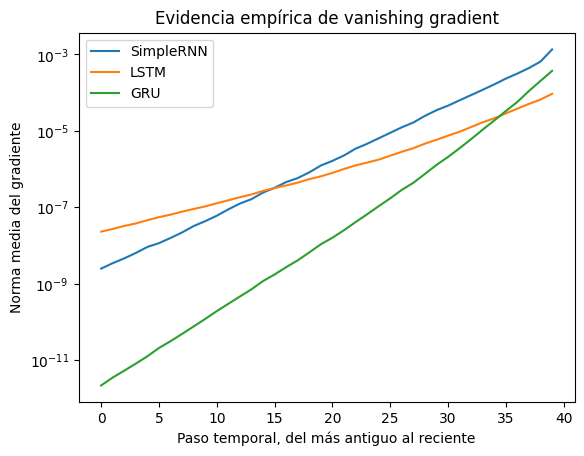

In [7]:
gradient_input = tf.random.normal((64, 40, 8), seed=2026)  # crea secuencias más largas para hacer visible la atenuación
gradient_curves = {}  # almacenará una norma media por paso y arquitectura
for layer_class in [tf.keras.layers.SimpleRNN, tf.keras.layers.LSTM, tf.keras.layers.GRU]:  # compara recurrencia simple y con compuertas
    recurrent = layer_class(32)  # utiliza la misma capacidad oculta para una comparación justa
    with tf.GradientTape() as tape:  # registra todas las operaciones necesarias para BPTT
        tape.watch(gradient_input)  # solicita explícitamente el gradiente respecto de la secuencia
        representation = recurrent(gradient_input)  # propaga cuarenta pasos hasta el último estado
        objective = tf.reduce_mean(tf.square(representation))  # define una pérdida escalar diferenciable
    gradients = tape.gradient(objective, gradient_input)  # aplica BPTT hasta cada entrada temporal
    norms = tf.reduce_mean(tf.norm(gradients, axis=2), axis=0).numpy()  # resume la fuerza del gradiente por paso
    gradient_curves[layer_class.__name__] = norms  # conserva la curva para graficarla
for name, norms in gradient_curves.items():  # recorre los tres mecanismos recurrentes
    plt.semilogy(norms, label=name)  # usa escala logarítmica para observar órdenes de magnitud
plt.xlabel('Paso temporal, del más antiguo al reciente')  # ubica el origen de cada gradiente
plt.ylabel('Norma media del gradiente')  # define la medida empírica de desvanecimiento
plt.title('Evidencia empírica de vanishing gradient')  # conecta el gráfico con la teoría BPTT
plt.legend()  # identifica SimpleRNN, LSTM y GRU
plt.show()  # presenta la evidencia final

## 5. Prueba integrada del torneo
La simulación juega 72 encuentros de grupos, clasifica 24 equipos por primera/segunda posición y ocho terceros, y completa 32 encuentros eliminatorios incluyendo tercer puesto.

In [8]:
from mundial.config import load_groups  # carga la configuración oficial editable de 48 selecciones
from mundial.inference import load_predictor  # recupera automáticamente el modelo neuronal recién exportado
from mundial.simulation import TournamentSimulator  # ejecuta grupos, mejores terceros y bracket oficial
predictor, mode = load_predictor()  # confirma que el artefacto real reemplazó al fallback de demostración
simulation = TournamentSimulator(predictor).simulate(load_groups(), runs=2000, seed=2026)  # estima el torneo completo de forma reproducible
top_ten = pd.Series(simulation.champion_probabilities).head(10).rename('probabilidad')  # selecciona los diez campeones más probables
display(top_ten.to_frame().style.format('{:.1%}'))  # presenta porcentajes legibles para periodistas
assert len(simulation.bracket) == 32  # comprueba los 32 partidos eliminatorios del formato 2026
assert abs(sum(simulation.champion_probabilities.values()) - 1.0) < 1e-9  # verifica conservación de probabilidad

,probabilidad
Argentina,12.1%
Portugal,11.5%
England,10.5%
Spain,10.2%
Germany,9.1%
France,8.8%
Belgium,6.5%
Brazil,6.2%
Netherlands,5.2%
Austria,2.5%


## Conclusiones y limitaciones

La selección final se fundamenta en macro F1 del Mundial 2022, no solo en accuracy. FC 24 es un proxy de las plantillas 2026; fair play no está disponible y se sustituye por sorteo reproducible; y una simulación no representa certeza deportiva, sino escenarios coherentes con las probabilidades estimadas.